# Quality control, step by step (QIQ December)
# 质量控制逐步演示（QIQ 12 月）

This notebook loads **December 2024** QIQ LR0100 data (`qiq1224.dat.gz`) and does two things:

1. **Part A — raw tests** — call functions in `ppl.py`, `erl.py`, `closure.py`, `diff_ratio.py`, `k_index.py`, and `tracker.py` directly. Each `*_test` returns **True = pass**. We print **failure row counts per subtest**; **the same row can fail several subtests**, so **sums across subtests are not unique rows**.
2. **Part B — wrapper** — run :func:`~bsrn.qc.wrapper.run_qc` on a **fresh copy** of the data to attach official `flag*` columns, then count **rows with any failure per tier** (unique rows within each tier).

本笔记本加载 QIQ **2024 年 12 月** LR0100 数据，分两部分：**A** 直接调用各模块 `*_test` 并统计每子测试失败行数（同一行可重复计入）；**B** 对干净副本调用 **`run_qc`** 生成 `flag*` 列并按层统计「至少一项失败」的行数。


## 1. Imports and path / 导入与路径

In [5]:
import os
import re

import numpy as np
import pandas as pd

import bsrn
from bsrn.constants import BSRN_STATIONS
from bsrn.physics import geometry
from bsrn.qc import closure, diff_ratio, erl, k_index, ppl, tracker
from bsrn.qc.wrapper import run_qc

# BSRN name pattern {ccc}{MM}{YY}.dat.gz (e.g. qiq1224 = QIQ Dec 2024); cwd = repo root
INPUT_FILE = "/Volumes/Macintosh Research/Data/bsrn-qc/data/QIQ/qiq1224.dat.gz"

_basename = os.path.basename(INPUT_FILE)
_m = re.match(r"^([A-Za-z]{3})", _basename)
if not _m:
    raise ValueError(f"Cannot parse BSRN station code from filename: {_basename}")
STATION_CODE = _m.group(1).upper()

pd.options.display.max_columns = None

## 2. Load data / 加载数据

In [6]:
df = bsrn.io.readers.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
if df is None:
    raise FileNotFoundError(f"Could not read {INPUT_FILE}. Download data for {STATION_CODE} first.")

print(f"Station: {STATION_CODE}  |  Rows: {len(df):,}  |  {df.index.min()} … {df.index.max()} UTC")
print("Columns:", ", ".join(df.columns))

Station: QIQ  |  Rows: 44,640  |  2024-12-01 00:00:00+00:00 … 2024-12-31 23:59:00+00:00 UTC
Columns: ghi, bni, dhi, lwd, temp, rh, pressure


## 3. Solar geometry (shared by all tests) / 太阳几何（各测试共用）

In [7]:
if STATION_CODE not in BSRN_STATIONS:
    raise KeyError(f"Unknown station {STATION_CODE} in BSRN_STATIONS")
meta = BSRN_STATIONS[STATION_CODE]
lat, lon, elev = meta["lat"], meta["lon"], meta["elev"]

solpos = geometry.get_solar_position(df.index, lat, lon, elev)
zenith = solpos["zenith"]
bni_extra = geometry.get_bni_extra(df.index)
ghi_extra = geometry.get_ghi_extra(df.index, zenith)

## 4. Part A — Individual `*_test` functions / A 部分 — 各 `*_test` 函数

Helpers: **`n_fail`** = rows where the test **fails** (i.e. pass is False). **`n_fail_any`** = rows where **at least one** of the given pass Series is False (unique rows within that list).

辅助函数：**`n_fail`** 为失败行数；**`n_fail_any`** 为「至少一项未通过」的行数（同一行只计一次）。


In [8]:
def n_fail(pass_bool):
    """Number of rows failing: *_test returns True=pass."""
    p = pass_bool if isinstance(pass_bool, pd.Series) else pd.Series(pass_bool, index=df.index)
    return int((~p.fillna(False)).sum())


def n_fail_any(*pass_series):
    """Rows where at least one test fails (unique rows; not sum of per-test counts)."""
    stacks = []
    for s in pass_series:
        p = s if isinstance(s, pd.Series) else pd.Series(s, index=df.index)
        stacks.append(p.fillna(False).to_numpy())
    all_pass = np.logical_and.reduce(stacks)
    return int((~all_pass).sum())

### 4.1 PPL (`ppl.py`)

In [9]:
pass_ghi = ppl.ghi_ppl_test(df["ghi"], zenith, bni_extra)
pass_bni = ppl.bni_ppl_test(df["bni"], bni_extra)
pass_dhi = ppl.dhi_ppl_test(df["dhi"], zenith, bni_extra)
print("PPL GHI fail rows:", n_fail(pass_ghi))
print("PPL BNI fail rows:", n_fail(pass_bni))
print("PPL DHI fail rows:", n_fail(pass_dhi))
if "lwd" in df.columns:
    pass_lwd = ppl.lwd_ppl_test(df["lwd"])
    print("PPL LWD fail rows:", n_fail(pass_lwd))
else:
    pass_lwd = None
    print("PPL LWD: (no lwd column)")
_ppl = [pass_ghi, pass_bni, pass_dhi] + ([pass_lwd] if pass_lwd is not None else [])
print("PPL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_ppl))
print("(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)")

PPL GHI fail rows: 0
PPL BNI fail rows: 0
PPL DHI fail rows: 0
PPL LWD fail rows: 0
PPL tier — rows failing ≥1 subtest (unique): 0
(Sum of the four counts above can exceed this if the same row fails multiple PPL tests.)


### 4.2 ERL (`erl.py`)

In [10]:
e_ghi = erl.ghi_erl_test(df["ghi"], zenith, bni_extra)
e_bni = erl.bni_erl_test(df["bni"], zenith, bni_extra)
e_dhi = erl.dhi_erl_test(df["dhi"], zenith, bni_extra)
print("ERL GHI fail rows:", n_fail(e_ghi))
print("ERL BNI fail rows:", n_fail(e_bni))
print("ERL DHI fail rows:", n_fail(e_dhi))
if "lwd" in df.columns:
    e_lwd = erl.lwd_erl_test(df["lwd"])
    print("ERL LWD fail rows:", n_fail(e_lwd))
else:
    e_lwd = None
_erl = [e_ghi, e_bni, e_dhi] + ([e_lwd] if e_lwd is not None else [])
print("ERL tier — rows failing ≥1 subtest (unique):", n_fail_any(*_erl))

ERL GHI fail rows: 9544
ERL BNI fail rows: 0
ERL DHI fail rows: 2216
ERL LWD fail rows: 0
ERL tier — rows failing ≥1 subtest (unique): 9552


### 4.3 Closure (`closure.py`)

In [11]:
c_low = closure.closure_low_sza_test(df["ghi"], df["bni"], df["dhi"], zenith)
c_high = closure.closure_high_sza_test(df["ghi"], df["bni"], df["dhi"], zenith)
print("Closure low-SZA  fail rows:", n_fail(c_low))
print("Closure high-SZA fail rows:", n_fail(c_high))
print("Closure tier — rows failing ≥1 subtest (unique):", n_fail_any(c_low, c_high))

Closure low-SZA  fail rows: 0
Closure high-SZA fail rows: 2
Closure tier — rows failing ≥1 subtest (unique): 2


### 4.4 Diffuse ratio (`diff_ratio.py`)

In [12]:
d_kkt = diff_ratio.k_kt_combined_test(df["ghi"], df["dhi"], bni_extra, zenith)
d_klo = diff_ratio.k_low_sza_test(df["ghi"], df["dhi"], zenith)
d_khi = diff_ratio.k_high_sza_test(df["ghi"], df["dhi"], zenith)
print("K–Kt combined fail rows:", n_fail(d_kkt))
print("k low-SZA       fail rows:", n_fail(d_klo))
print("k high-SZA      fail rows:", n_fail(d_khi))
print("Diffuse-ratio tier — rows failing ≥1 subtest (unique):", n_fail_any(d_kkt, d_klo, d_khi))

K–Kt combined fail rows: 3
k low-SZA       fail rows: 0
k high-SZA      fail rows: 0
Diffuse-ratio tier — rows failing ≥1 subtest (unique): 3


### 4.5 K-indices (`k_index.py`)

In [13]:
k_kbkt = k_index.kb_kt_test(df["ghi"], df["bni"], bni_extra, zenith)
k_kb = k_index.kb_limit_test(df["bni"], bni_extra, elev, df["ghi"])
k_kt = k_index.kt_limit_test(df["ghi"], bni_extra, zenith)
print("Kb vs Kt fail rows:", n_fail(k_kbkt))
print("Kb limit   fail rows:", n_fail(k_kb))
print("Kt limit   fail rows:", n_fail(k_kt))
print("K-index tier — rows failing ≥1 subtest (unique):", n_fail_any(k_kbkt, k_kb, k_kt))

Kb vs Kt fail rows: 0
Kb limit   fail rows: 0
Kt limit   fail rows: 0
K-index tier — rows failing ≥1 subtest (unique): 0


### 4.6 Tracker (`tracker.py`)

In [14]:
pass_trk = tracker.tracker_off_test(
    df["ghi"], df["bni"], zenith, ghi_extra=ghi_extra, ghi_clear=None, bni_clear=None
)
print("Tracker-off fail rows:", n_fail(pass_trk))

Tracker-off fail rows: 47


## 5. Part B — `run_qc` and tier row counts / B 部分 — `run_qc` 与各层行数

Run the library wrapper on a **clean copy** of the data, then count rows with **≥1 failure** in each tier from the **`flag*`** columns (**1 = fail**). Within a tier, a row is counted **once** if any flag in that tier is 1.

对干净副本运行 **`run_qc`**，再按各层 **`flag*`** 统计「至少一项未通过」的行数（**1 = 未通过**）。同一层内任一子项为 1 则该行在该层计一次。

The mapping of flags to tiers is stored in **`TIER_COLS`** for reuse in §7.

层与 `flag*` 的对应关系保存在 **`TIER_COLS`** 中，供 §7 复用。


In [15]:
df_qc = run_qc(df.copy(), station_code=STATION_CODE)

TIER_COLS = {
    "PPL": [c for c in df_qc.columns if c.startswith("flagPPL")],
    "ERL": [c for c in df_qc.columns if c.startswith("flagERL")],
    "Closure": [c for c in df_qc.columns if c.startswith("flag3")],
    "Diffuse k / K–Kt": ["flagKKt", "flagKlowSZA", "flagKhighSZA"],
    "K-indices": ["flagKbKt", "flagKb", "flagKt"],
    "Tracker": ["flagTracker"],
}

rows = len(df_qc)
print(f"Total rows: {rows:,}")
print("--- Part B: rows with ≥1 fail per tier (flag* columns) ---")
for name, want in TIER_COLS.items():
    cols = [c for c in want if c in df_qc.columns]
    if not cols:
        continue
    n = int(df_qc[cols].eq(1).any(axis=1).sum())
    print(f"{name}: rows with ≥1 fail in tier = {n:,}  (flags: {', '.join(cols)})")

Total rows: 44,640
--- Part B: rows with ≥1 fail per tier (flag* columns) ---
PPL: rows with ≥1 fail in tier = 0  (flags: flagPPLGHI, flagPPLBNI, flagPPLDHI, flagPPLLWD)
ERL: rows with ≥1 fail in tier = 9,552  (flags: flagERLGHI, flagERLBNI, flagERLDHI, flagERLLWD)
Closure: rows with ≥1 fail in tier = 2  (flags: flag3lowSZA, flag3highSZA)
Diffuse k / K–Kt: rows with ≥1 fail in tier = 3  (flags: flagKKt, flagKlowSZA, flagKhighSZA)
K-indices: rows with ≥1 fail in tier = 0  (flags: flagKbKt, flagKb, flagKt)
Tracker: rows with ≥1 fail in tier = 47  (flags: flagTracker)


## 6. Compare Part A vs Part B (per tier) / 对比 A 与 B（按层）

**Part A** uses raw `*_test` pass/fail booleans and **`n_fail_any`** (tier unique fail rows from §4). **Part B** uses **`run_qc`** `flag*` columns with the same tier groupings. Counts should **match** for each tier.

**A 部分** 为 §4 中原始 `*_test` 与 **`n_fail_any`** 的按层失败行数；**B 部分** 为 **`run_qc`** 的 `flag*`。各层计数应**一致**。

Optional: per-flag sums (wrapper) in the next cell.

可选：下一单元为各 `flag*` 失败次数（非按层唯一行）。


In [16]:
part_a_tier = {
    "PPL": n_fail_any(*_ppl),
    "ERL": n_fail_any(*_erl),
    "Closure": n_fail_any(c_low, c_high),
    "Diffuse k / K–Kt": n_fail_any(d_kkt, d_klo, d_khi),
    "K-indices": n_fail_any(k_kbkt, k_kb, k_kt),
    "Tracker": n_fail(pass_trk),
}

part_b_tier = {}
for name, want in TIER_COLS.items():
    cols = [c for c in want if c in df_qc.columns]
    if cols:
        part_b_tier[name] = int(df_qc[cols].eq(1).any(axis=1).sum())

cmp = pd.DataFrame(
    {
        "Part A (§4 raw *_test, tier unique fails)": pd.Series(part_a_tier),
        "Part B (§5 run_qc flag*, any fail in tier)": pd.Series(part_b_tier),
    }
)
cmp["match"] = cmp.iloc[:, 0] == cmp.iloc[:, 1]
cmp

,"Part A (§4 raw *_test, tier unique fails)","Part B (§5 run_qc flag*, any fail in tier)",match
PPL,0,0,True
ERL,9552,9552,True
Closure,2,2,True
Diffuse k / K–Kt,3,3,True
K-indices,0,0,True
Tracker,47,47,True


In [17]:
flag_cols = [c for c in df_qc.columns if c.startswith("flag")]
df_qc[flag_cols].sum().sort_index()

flag3highSZA       2
flag3lowSZA        0
flagERLBNI         0
flagERLDHI      2216
flagERLGHI      9544
flagERLLWD         0
flagKKt            3
flagKb             0
flagKbKt           0
flagKhighSZA       0
flagKlowSZA        0
flagKt             0
flagPPLBNI         0
flagPPLDHI         0
flagPPLGHI         0
flagPPLLWD         0
flagTracker       47
dtype: int64

## 8. Tracker-off test: one UTC day where the test fails / 跟踪器失准：失败日示例

**§4.6** `tracker.tracker_off_test` returns **True = pass** when the tracker is **not** suspected off: measured GHI is close to the clear-sky reference while BNI is **not** far below its reference (with `zenith < 85°`). **Part B** sets **`flagTracker == 1`** when that test **fails** (same rows as `~pass_trk` in §4.6).

Below we pick **one UTC calendar day** that contains at least one `flagTracker == 1` minute and plot **measured GHI & BNI**, the **GHIC / BNIC** fallbacks used inside the test (`GHIC = 0.8 × GHIE`, then DHIC and BNIC as in `tracker.py`), **solar zenith**, and a **red tint** where `flagTracker == 1`.

**§4.6** `tracker.tracker_off_test` 在**未**怀疑跟踪器失准时为 **True = 通过**。**Part B** 中 **`flagTracker == 1`** 表示该测试**未通过**（与 §4.6 中 `~pass_trk` 一致）。

下面选取含至少一行 **`flagTracker == 1`** 的 **UTC 日**，绘制测量 GHI、BNI、测试内晴空参考（GHIC、BNIC）与太阳天顶角；**红色淡阴影**标出 `flagTracker == 1` 的时刻。

**Important:** A flag is **not** a proof of a bad instrument. **Rule-based tests can mislabel** plausible minutes (e.g. thin clouds, calibration, or a crude clear-sky reference). **Visual inspection**—checking whether the pattern matches a real tracker problem—is therefore **essential**: treat the plot as a prompt to **look**, not as automatic ground truth.

**要点：** 被标旗**不等于**观测一定有问题。**基于规则**的判定可能**误判**（例如薄云、定标或粗糙晴空参考）。**目视检查**是否真像跟踪器失准**非常重要**：把图当作**提醒**去人工核对，**不要**把旗标当作绝对结论。

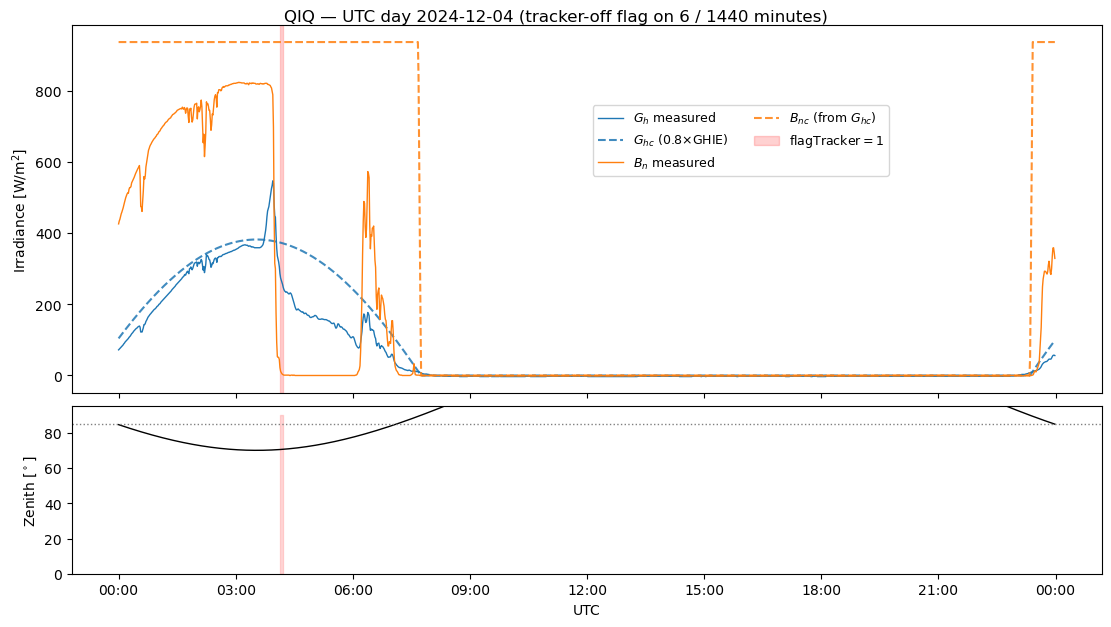

In [18]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

bad_trk = df_qc.index[df_qc["flagTracker"].eq(1)]
if len(bad_trk) == 0:
    print("No tracker failures this month — nothing to plot.")
else:
    # First UTC day with any failure (alternatively: bad_trk.normalize().value_counts().idxmax())
    day0 = bad_trk[0].normalize()
    day1 = day0 + pd.Timedelta(days=1)
    d = df_qc.loc[(df_qc.index >= day0) & (df_qc.index < day1)]
    z = zenith.loc[d.index]

    # Same clear-sky references as tracker_off_test defaults / 与 tracker_off_test 默认晴空参考一致
    ghi_e = geometry.get_ghi_extra(d.index, z)
    ghi_c = 0.8 * ghi_e
    mu0 = np.cos(np.radians(z))
    # BNIC from GHIC and DHIC = 0.165 * GHIC (same as tracker_off_test) / 与 tracker_off_test 相同
    bni_c = (ghi_c - 0.165 * ghi_c) / np.maximum(mu0, 0.01)

    fail = d["flagTracker"].eq(1).to_numpy()

    fig, (ax_irr, ax_z) = plt.subplots(
        2, 1, figsize=(11, 6), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [2.2, 1]}
    )
    ax_irr.plot(d.index, d["ghi"], label=r"$G_h$ measured", color="C0", lw=1)
    ax_irr.plot(d.index, ghi_c, label=r"$G_{hc}$ (0.8×GHIE)", color="C0", ls="--", alpha=0.85)
    ax_irr.plot(d.index, d["bni"], label=r"$B_n$ measured", color="C1", lw=1)
    ax_irr.plot(d.index, bni_c, label=r"$B_{nc}$ (from $G_{hc}$)", color="C1", ls="--", alpha=0.85)
    ax_irr.fill_between(
        d.index,
        0,
        1,
        where=fail,
        transform=ax_irr.get_xaxis_transform(),
        color="red",
        alpha=0.18,
    )
    ax_irr.set_ylabel(r"Irradiance [W/m$^2$]")
    leg_lines = ax_irr.get_lines()
    leg_lbl = [ln.get_label() for ln in leg_lines]
    leg_lines.append(mpatches.Patch(color="red", alpha=0.18, label=r"flagTracker$=$1"))
    leg_lbl.append(r"flagTracker$=$1")
    ax_irr.legend(
        leg_lines,
        leg_lbl,
        loc="upper left",
        bbox_to_anchor=(0.5, 0.8),
        fontsize=9,
        ncol=2,
    )

    ax_z.plot(d.index, z, color="k", lw=1)
    ax_z.axhline(85, color="gray", ls=":", lw=1)
    ax_z.set_ylabel(r"Zenith [$^\circ$]")
    ax_z.set_xlabel("UTC")
    ax_z.fill_between(d.index, 0, 90, where=fail, color="red", alpha=0.15)
    ax_z.set_ylim(0, 95)

    ax_irr.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.suptitle(f"{STATION_CODE} — UTC day {day0.date()} (tracker-off flag on {fail.sum()} / {len(d)} minutes)", y=1.02)
    plt.show()